In [ ]:
# IMPORT NEEDED PACKAGES 
import pandas as pd
import numpy as np

from tqdm import tqdm
import pickle
from collections import Counter
import h5py


import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import ast


from sklearn.neighbors import NearestNeighbors

# PATHS
path_save = './LINCS_scGPT_embeddings/Results/MoA_Annotation/'
root_LINCS = './LINCS_scGPT_embeddings/02_Obtain_Embeddings/embeddings_full.h5ad'


# LOAD DATA
## ADATA: embeddings

adata = sc.read(root_LINCS)
adata = adata[adata.obs.pert_type == 'trt_cp'].copy()
sig2pert = dict(zip(adata.obs_names, adata.obs.pert_id))

## Metadata
cmp_info = pd.read_csv('./LINCS_scGPT_embeddings/Data/Intermediate_files/cmp_info.txt', sep = '\t')
cmp_info.dropna(subset=['moa'], inplace=True)
cmp_info_moa = cmp_info[['pert_id', 'moa']].drop_duplicates()
pert2moa = cmp_info_moa.groupby("pert_id")["moa"].apply(list).to_dict()

In [ ]:
## Distances and indices
# =============================================================================
# You need to run ./LINCS_scGPT_embeddings/03_Distance_Integration/NN_calculation.py using: 
# - reference: embeddings from compounds with known MoA (annotated) - pert_id2moa keys
# - query: embeddings from compounds without known MoA (unannotated)

## Distances and indices
with h5py.File(path_save + 'cmp_distances_unanot.h5', 'r') as f:
    indices_unanot = f['indices'][:]
    distances_unanot = f['distances'][:]


cmp_order_unanot = pickle.load(open(path_save + 'cmp_order_unanot.pkl', 'rb'))
cmp_order_annot = pickle.load(open(path_save + 'cmp_order_annot.pkl', 'rb'))

In [ ]:
adata.obs['moa_list'] = [pert2moa.get(pid, None) for pid in adata.obs['pert_id'].values]
adata_annot = adata[cmp_order_annot].copy()
adata_unannot = adata[cmp_order_unanot].copy()

# 1. Compound colapse voting

First collapse by reference compound and then count how many times each compound is a nearest neighbor. Then, map to MoA and count how many times each MoA is a nearest neighbor. This way, we can get a more accurate picture of which MoAs are most commonly found as nearest neighbors, without being biased by compounds that have many signatures in the dataset.

In [17]:
import numpy as np
import pandas as pd

def moa_propagation_reference_compound_level(
    adata_unannot,
    adata_annot,
    pert2moa,
    indices,
    distances,
    query_pert_key="pert_id",
    ref_pert_key="pert_id",
    k_raw=50,
    weighting="softmax",   # "uniform" | "inverse" | "softmax"
    temperature=0.07,
    collapse_mode="closest",   # "closest" | "sum"
    min_unique_ref_compounds=3,
):
    """
    MoA predictions for unannotated compounds by looking at their nearest neighbors among annotated compounds.

    Query side:
        predicts per query sample, then aggregates to query compound.

    Reference side:
        collapses annotated sample neighbors into annotated compounds.

    Returns
    -------
    sample_probs : DataFrame
    sample_top : DataFrame
    compound_probs : DataFrame
    compound_top : DataFrame
    """

    def top_label_with_ties(row, sep=";"):
        max_val = row.max()
        tied = row.index[np.isclose(row.values, max_val)]
        return sep.join(tied)

    def moa_string_to_set(x, sep=";"):
        if pd.isna(x) or x == "":
            return set()
        return set(str(x).split(sep))

    def compute_weights(d, weighting, temperature):
        if weighting == "uniform":
            w = np.ones_like(d, dtype=float)
        elif weighting == "inverse":
            w = 1.0 / (d + 1e-8)
        elif weighting == "softmax":
            z = -d / max(temperature, 1e-8)
            z = z - z.max()
            w = np.exp(z)
        else:
            raise ValueError("weighting must be 'uniform', 'inverse', or 'softmax'")
        return w / (w.sum() + 1e-12)

    # ---------- reference metadata ----------
    ref_obs = adata_annot.obs.copy().reset_index(drop=True)
    ref_obs["moa_list"] = [pert2moa.get(pid, None) for pid in ref_obs[ref_pert_key].values]

    ref_valid = ref_obs["moa_list"].apply(lambda x: isinstance(x, list) and len(x) > 0).values

    # all MoAs in valid references
    all_moas = sorted(pd.unique(pd.Series(
        [m for ms in ref_obs.loc[ref_valid, "moa_list"] for m in ms]
    )))
    moa_to_i = {m: i for i, m in enumerate(all_moas)}

    # query metadata
    query_obs = adata_unannot.obs.copy()
    query_compounds = query_obs[query_pert_key].values
    query_sample_ids = adata_unannot.obs_names.to_numpy()

    n_query = adata_unannot.n_obs
    P = np.zeros((n_query, len(all_moas)), dtype=float)

    unique_ref_counts = np.zeros(n_query, dtype=int)
    support_top_moa_count = np.zeros(n_query, dtype=int)
    support_top_moa_weight = np.zeros(n_query, dtype=float)

    # store per-sample collapsed refs to compute support after P is known
    collapsed_cmp_ids_per_sample = [None] * n_query
    collapsed_W_per_sample = [None] * n_query

    # ---------- per-query-sample propagation ----------
    for i in range(n_query):
        neigh_idx = indices[i, :k_raw]
        neigh_dist = distances[i, :k_raw]

        # keep only valid annotated refs with MoA
        keep = ref_valid[neigh_idx]
        neigh_idx = neigh_idx[keep]
        neigh_dist = neigh_dist[keep]

        if len(neigh_idx) == 0:
            continue

        ref_compounds = ref_obs.loc[neigh_idx, ref_pert_key].values

        if collapse_mode == "closest":
            # keep closest sample per reference compound
            best = {}
            for j, d, cmp_id in zip(neigh_idx, neigh_dist, ref_compounds):
                if (cmp_id not in best) or (d < best[cmp_id][1]):
                    best[cmp_id] = (j, d)

            cmp_ids = np.array(list(best.keys()), dtype=object)
            cmp_best_dist = np.array([best[c][1] for c in cmp_ids], dtype=float)

            unique_ref_counts[i] = len(cmp_ids)

            if len(cmp_ids) < min_unique_ref_compounds:
                continue

            W = compute_weights(cmp_best_dist, weighting, temperature)

            collapsed_cmp_ids_per_sample[i] = cmp_ids
            collapsed_W_per_sample[i] = W

            for w, cmp_id in zip(W, cmp_ids):
                moas = pert2moa.get(cmp_id, None)
                if not (isinstance(moas, list) and len(moas) > 0):
                    continue
                share = w / len(moas)
                for m in moas:
                    if m in moa_to_i:
                        P[i, moa_to_i[m]] += share

        elif collapse_mode == "sum":
            w_sample = compute_weights(neigh_dist, weighting, temperature)

            cmp_weight = {}
            for cmp_id, w in zip(ref_compounds, w_sample):
                cmp_weight[cmp_id] = cmp_weight.get(cmp_id, 0.0) + w

            unique_ref_counts[i] = len(cmp_weight)

            if len(cmp_weight) < min_unique_ref_compounds:
                continue

            cmp_ids = np.array(list(cmp_weight.keys()), dtype=object)
            W = np.array([cmp_weight[c] for c in cmp_ids], dtype=float)
            W = W / (W.sum() + 1e-12)

            collapsed_cmp_ids_per_sample[i] = cmp_ids
            collapsed_W_per_sample[i] = W

            for w, cmp_id in zip(W, cmp_ids):
                moas = pert2moa.get(cmp_id, None)
                if not (isinstance(moas, list) and len(moas) > 0):
                    continue
                share = w / len(moas)
                for m in moas:
                    if m in moa_to_i:
                        P[i, moa_to_i[m]] += share

        else:
            raise ValueError("collapse_mode must be 'closest' or 'sum'")

    # safe normalize
    P = P / (P.sum(axis=1, keepdims=True) + 1e-12)

    # ---------- outputs: sample level ----------
    sample_probs = pd.DataFrame(P, index=query_sample_ids, columns=all_moas)

    sample_top_moa = sample_probs.apply(top_label_with_ties, axis=1)
    sample_top_conf = sample_probs.max(axis=1)

    # compute support_top_moa at sample level
    for i in range(n_query):
        cmp_ids = collapsed_cmp_ids_per_sample[i]
        W = collapsed_W_per_sample[i]

        if cmp_ids is None or W is None:
            continue

        top_moa_set = moa_string_to_set(sample_top_moa.iloc[i])

        count_support = 0
        weight_support = 0.0

        for cmp_id, w in zip(cmp_ids, W):
            moas = pert2moa.get(cmp_id, [])
            if any(m in top_moa_set for m in moas):
                count_support += 1
                weight_support += w

        support_top_moa_count[i] = count_support
        support_top_moa_weight[i] = weight_support

    sample_top = pd.DataFrame({
        query_pert_key: query_compounds,
        "top_moa": sample_top_moa,
        "top_conf": sample_top_conf,
        "n_unique_ref_compounds": unique_ref_counts,
        "support_top_moa_count": support_top_moa_count,
        "support_top_moa_weight": support_top_moa_weight,
    }, index=query_sample_ids)

    # ---------- outputs: query compound level ----------
    compound_probs = sample_probs.copy()
    compound_probs[query_pert_key] = query_compounds
    compound_probs = compound_probs.groupby(query_pert_key)[all_moas].mean()

    compound_top_moa = compound_probs.apply(top_label_with_ties, axis=1)
    compound_top_conf = compound_probs.max(axis=1)

    # ---------- agreement with partial overlap ----------
    tmp = sample_top.reset_index().rename(columns={"index": "sample_id"})[
        [query_pert_key, "top_moa"]
    ].copy()

    tmp["sample_top_set"] = tmp["top_moa"].apply(moa_string_to_set)

    compound_top_sets = compound_top_moa.apply(moa_string_to_set)
    compound_top_sets_dict = compound_top_sets.to_dict()

    def has_overlap(sample_set, compound_set):
        return len(sample_set & compound_set) > 0

    tmp["compound_top_set"] = tmp[query_pert_key].astype(object).apply(
        lambda x: compound_top_sets_dict.get(x, set())
    )
    tmp["partial_match"] = tmp.apply(
        lambda row: has_overlap(row["sample_top_set"], row["compound_top_set"]),
        axis=1
    )

    agreement = (
        tmp.groupby(query_pert_key)["partial_match"]
        .mean()
        .reindex(compound_probs.index)
        .fillna(0.0)
    )

    n_per = tmp.groupby(query_pert_key).size().rename("n_samples")

    # mean metrics across query samples
    mean_unique_ref = (
        sample_top.groupby(query_pert_key)["n_unique_ref_compounds"]
        .mean()
        .reindex(compound_probs.index)
    )

    mean_support_top_moa_count = (
        sample_top.groupby(query_pert_key)["support_top_moa_count"]
        .mean()
        .reindex(compound_probs.index)
    )

    mean_support_top_moa_weight = (
        sample_top.groupby(query_pert_key)["support_top_moa_weight"]
        .mean()
        .reindex(compound_probs.index)
    )

    compound_top = pd.DataFrame({
        "top_moa": compound_top_moa,
        "top_conf": compound_top_conf,
        "agreement": agreement,
        "n_samples": n_per.reindex(compound_probs.index),
        "mean_unique_ref_compounds": mean_unique_ref,
        "mean_support_top_moa_count": mean_support_top_moa_count,
    })

    return sample_probs, sample_top, compound_probs, compound_top

In [18]:
sample_probs, sample_top, compound_probs, compound_top = (
    moa_propagation_reference_compound_level(
        adata_unannot=adata_unannot,
        adata_annot=adata_annot,
        pert2moa=pert2moa,
        indices=indices_unanot,
        distances=distances_unanot,
        query_pert_key="pert_id",
        ref_pert_key="pert_id",
        k_raw=50,
        weighting="softmax",
        temperature=0.07,
        collapse_mode="closest",   # start with this
        min_unique_ref_compounds=3,
    )
)

/tmp/ipykernel_495510/1653854016.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compound_probs = compound_probs.groupby(query_pert_key)[all_moas].mean()
/tmp/ipykernel_495510/1653854016.py:231: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(query_pert_key)["partial_match"]
/tmp/ipykernel_495510/1653854016.py:237: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_per = tmp.groupby(query_pert_key).size().re

In [19]:
compound_top = compound_top[compound_top.mean_support_top_moa_count != 0]
pert2cmap = dict(zip(adata.obs['pert_id'], adata.obs['cmap_name']))
compound_top['cmap_name'] = compound_top.index.map(pert2cmap)
compound_top.index = compound_top.index.astype(str)

In [ ]:
compound_top.to_csv(path_save + 'MoA_annotations_all.csv')
compound_top[compound_top.top_conf > 0.25].to_csv(path_save + 'MoA_annotations_highconf.csv')

# 2. Paper Analysis

## Benchmark with annotated set

In [ ]:
# For the nearest neighbor search, we used FAISS for efficient similarity search on GPU. 
# If no GPU is available, computation time can be significantly longer. 

import numpy as np
import scanpy as sc
from scipy.spatial.distance import cdist
from tqdm import tqdm
import pickle
import sys
import os
from sklearn.metrics import roc_curve, roc_auc_score
import faiss
import h5py
import numpy as np
from tqdm import tqdm

unnanotated_order = []
annotated_order = []
indices = []
distances = []
unique_annotated_drugs = adata_annot.obs.pert_id.unique()

for i in tqdm(unique_annotated_drugs): 
    data_cmp_unanot = adata_annot[adata_annot.obs.pert_id == i].obsm["X_scGPT"].copy()
    data_cmp_annot = adata_annot[adata_annot.obs.pert_id != i].obsm["X_scGPT"].copy()

    def as_float32(X):
        X = np.asarray(X)
        if X.dtype != np.float32:
            X = X.astype(np.float32)
        return X

    def l2norm_inplace(X):
        faiss.normalize_L2(X)  # in-place

    l2norm_inplace(data_cmp_unanot)
    l2norm_inplace(data_cmp_annot)


    index = faiss.IndexFlatIP(data_cmp_annot.shape[1])  # Inner Product (IP) flat index
    if faiss.get_num_gpus() > 0:
        index = faiss.index_cpu_to_all_gpus(index)  # Use all GPUs

    index.add(data_cmp_annot) 
    k=2048
    batch_size=10

    unnanotated_order.append(adata_annot[adata_annot.obs.pert_id == i].obs_names)
    annotated_order.append(adata_annot[adata_annot.obs.pert_id != i].obs_names)

    distances_cmp, indices_cmp = index.search(data_cmp_unanot, k)  # Search for the k nearest neighbors
    indices.append(indices_cmp)
    distances.append(distances_cmp)

pickle.dump(unnanotated_order, open(path_save + 'unnanotated_order_benchmark_moa.pkl', 'wb'))
pickle.dump(annotated_order, open(path_save + 'annotated_order_benchmark_moa.pkl', 'wb'))
pickle.dump(indices, open(path_save + 'indices_benchmark_moa.pkl', 'wb'))
pickle.dump(distances, open(path_save + 'distances_benchmark_moa.pkl', 'wb'))

In [ ]:
unnanotated_order = pickle.load(open(path_save + 'unnanotated_order_benchmark_moa.pkl', 'rb'))
annotated_order = pickle.load(open(path_save + 'annotated_order_benchmark_moa.pkl', 'rb'))
indices = pickle.load(open(path_save + 'indices_benchmark_moa.pkl', 'rb'))
distances = pickle.load(open(path_save + 'distances_benchmark_moa.pkl', 'rb'))

In [5]:
import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from tqdm.auto import tqdm


def moa_propagation_benchmark_compound_level_parallel(
    obs,
    pert2moa,
    unannotated_order,
    annotated_order,
    indices,
    distances,
    pert_key="pert_id",
    k_raw=50,
    weighting="softmax",
    temperature=0.07,
    collapse_mode="closest",
    min_unique_ref_compounds=3,
    sample_id_col=None,
    n_jobs=8,
    backend="loky",
):
    def top_label_with_ties(row, sep=";"):
        max_val = row.max()
        tied = row.index[np.isclose(row.values, max_val)]
        return sep.join(tied)

    def moa_string_to_set(x, sep=";"):
        if pd.isna(x) or x == "":
            return set()
        return set(str(x).split(sep))

    def compute_weights(d):
        if weighting == "uniform":
            w = np.ones_like(d, dtype=float)
        elif weighting == "inverse":
            w = 1.0 / (d + 1e-8)
        elif weighting == "softmax":
            z = -d / max(temperature, 1e-8)
            z = z - z.max()
            w = np.exp(z)
        else:
            raise ValueError("weighting must be 'uniform', 'inverse', or 'softmax'")
        return w / (w.sum() + 1e-12)

    def subset_obs(order):
        order = np.asarray(order)

        if sample_id_col is not None:
            return obs.set_index(sample_id_col).loc[order].copy()

        if np.issubdtype(order.dtype, np.integer):
            return obs.iloc[order].copy()

        return obs.loc[order].copy()

    all_moas = sorted({
        m
        for moas in pert2moa.values()
        if isinstance(moas, list)
        for m in moas
    })

    moa_to_i = {m: i for i, m in enumerate(all_moas)}
    n_moas = len(all_moas)

    def process_one_split(split_id, query_order, ref_order, idx_mat, dist_mat):
        query_obs = subset_obs(query_order)
        ref_obs = subset_obs(ref_order).reset_index(drop=True)

        query_sample_ids = query_obs.index.to_numpy()
        query_compounds = query_obs[pert_key].to_numpy()

        ref_pert_array = ref_obs[pert_key].to_numpy()

        ref_moa_array = np.array([
            pert2moa.get(pid, None)
            for pid in ref_pert_array
        ], dtype=object)

        ref_valid = np.array([
            isinstance(x, list) and len(x) > 0
            for x in ref_moa_array
        ], dtype=bool)

        n_query = len(query_obs)

        P = np.zeros((n_query, n_moas), dtype=float)

        unique_ref_counts = np.zeros(n_query, dtype=int)
        support_top_moa_count = np.zeros(n_query, dtype=int)
        support_top_moa_weight = np.zeros(n_query, dtype=float)

        collapsed_cmp_ids_per_sample = [None] * n_query
        collapsed_W_per_sample = [None] * n_query

        for i in range(n_query):
            neigh_idx = idx_mat[i, :k_raw]
            neigh_dist = dist_mat[i, :k_raw]

            keep = ref_valid[neigh_idx]
            neigh_idx = neigh_idx[keep]
            neigh_dist = neigh_dist[keep]

            if len(neigh_idx) == 0:
                continue

            ref_compounds = ref_pert_array[neigh_idx]

            if collapse_mode == "closest":
                best = {}

                for d, cmp_id in zip(neigh_dist, ref_compounds):
                    if cmp_id not in best or d < best[cmp_id]:
                        best[cmp_id] = d

                cmp_ids = np.array(list(best.keys()), dtype=object)
                cmp_dist = np.array([best[c] for c in cmp_ids], dtype=float)

                unique_ref_counts[i] = len(cmp_ids)

                if len(cmp_ids) < min_unique_ref_compounds:
                    continue

                W = compute_weights(cmp_dist)

            elif collapse_mode == "sum":
                w_sample = compute_weights(neigh_dist)

                cmp_weight = {}

                for cmp_id, w in zip(ref_compounds, w_sample):
                    cmp_weight[cmp_id] = cmp_weight.get(cmp_id, 0.0) + w

                unique_ref_counts[i] = len(cmp_weight)

                if len(cmp_weight) < min_unique_ref_compounds:
                    continue

                cmp_ids = np.array(list(cmp_weight.keys()), dtype=object)
                W = np.array([cmp_weight[c] for c in cmp_ids], dtype=float)
                W = W / (W.sum() + 1e-12)

            else:
                raise ValueError("collapse_mode must be 'closest' or 'sum'")

            collapsed_cmp_ids_per_sample[i] = cmp_ids
            collapsed_W_per_sample[i] = W

            for w, cmp_id in zip(W, cmp_ids):
                moas = pert2moa.get(cmp_id, None)

                if not isinstance(moas, list) or len(moas) == 0:
                    continue

                share = w / len(moas)

                for m in moas:
                    j = moa_to_i.get(m, None)
                    if j is not None:
                        P[i, j] += share

        P = P / (P.sum(axis=1, keepdims=True) + 1e-12)

        sample_probs = pd.DataFrame(P, index=query_sample_ids, columns=all_moas)
        sample_probs["split_id"] = split_id
        sample_probs[pert_key] = query_compounds

        sample_top_moa = sample_probs[all_moas].apply(top_label_with_ties, axis=1)
        sample_top_conf = sample_probs[all_moas].max(axis=1)

        for i in range(n_query):
            cmp_ids = collapsed_cmp_ids_per_sample[i]
            W = collapsed_W_per_sample[i]

            if cmp_ids is None or W is None:
                continue

            top_moa_set = moa_string_to_set(sample_top_moa.iloc[i])

            count_support = 0
            weight_support = 0.0

            for cmp_id, w in zip(cmp_ids, W):
                moas = pert2moa.get(cmp_id, [])
                if any(m in top_moa_set for m in moas):
                    count_support += 1
                    weight_support += w

            support_top_moa_count[i] = count_support
            support_top_moa_weight[i] = weight_support

        sample_top = pd.DataFrame({
            "split_id": split_id,
            pert_key: query_compounds,
            "top_moa": sample_top_moa,
            "top_conf": sample_top_conf,
            "n_unique_ref_compounds": unique_ref_counts,
            "support_top_moa_count": support_top_moa_count,
            "support_top_moa_weight": support_top_moa_weight,
        }, index=query_sample_ids)

        return sample_probs, sample_top

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(process_one_split)(
            split_id,
            query_order,
            ref_order,
            idx_mat,
            dist_mat,
        )
        for split_id, (query_order, ref_order, idx_mat, dist_mat)
        in tqdm(
            enumerate(zip(unannotated_order, annotated_order, indices, distances)),
            total=len(unannotated_order),
            desc="Processing benchmark splits",
        )
    )

    all_sample_probs, all_sample_top = zip(*results)

    sample_probs = pd.concat(all_sample_probs, axis=0)
    sample_top = pd.concat(all_sample_top, axis=0)

    compound_probs = (
        sample_probs
        .groupby(pert_key)[all_moas]
        .mean()
    )

    compound_top_moa = compound_probs.apply(top_label_with_ties, axis=1)
    compound_top_conf = compound_probs.max(axis=1)

    tmp = sample_top.reset_index().rename(columns={"index": "sample_id"})[
        [pert_key, "top_moa"]
    ].copy()

    tmp["sample_top_set"] = tmp["top_moa"].apply(moa_string_to_set)

    compound_top_sets = compound_top_moa.apply(moa_string_to_set).to_dict()

    tmp["compound_top_set"] = tmp[pert_key].apply(
        lambda x: compound_top_sets.get(x, set())
    )

    tmp["partial_match"] = tmp.apply(
        lambda row: len(row["sample_top_set"] & row["compound_top_set"]) > 0,
        axis=1,
    )

    agreement = (
        tmp.groupby(pert_key)["partial_match"]
        .mean()
        .reindex(compound_probs.index)
        .fillna(0.0)
    )

    compound_top = pd.DataFrame({
        "top_moa": compound_top_moa,
        "top_conf": compound_top_conf,
        "agreement": agreement,
        "n_samples": sample_top.groupby(pert_key).size().reindex(compound_probs.index),
        "mean_unique_ref_compounds": sample_top.groupby(pert_key)["n_unique_ref_compounds"].mean().reindex(compound_probs.index),
        "mean_support_top_moa_count": sample_top.groupby(pert_key)["support_top_moa_count"].mean().reindex(compound_probs.index),
        "mean_support_top_moa_weight": sample_top.groupby(pert_key)["support_top_moa_weight"].mean().reindex(compound_probs.index),
    })

    return sample_probs, sample_top, compound_probs, compound_top

In [6]:
sample_probs_bench, sample_top_bench, compound_probs_bench, compound_top_bench = (
    moa_propagation_benchmark_compound_level_parallel(
        obs=adata_annot.obs,
        pert2moa=pert2moa,
        unannotated_order=unnanotated_order,
        annotated_order=annotated_order,
        indices=indices,
        distances=distances,
        pert_key="pert_id",
        k_raw=50,
        weighting="softmax",
        temperature=0.07,
        collapse_mode="closest",
        min_unique_ref_compounds=3,
        n_jobs=8,
    )
)

Processing benchmark splits:   0%|          | 0/3162 [00:00<?, ?it/s]

In [7]:
compound_top_bench['true_moa'] = compound_top_bench.index.map(pert2moa)
list_of_moas_with_more_than_one = cmp_info_moa.moa.value_counts()[cmp_info_moa.moa.value_counts() > 1].index.tolist()
compound_top_filtered_bench = compound_top_bench[compound_top_bench.index.isin(cmp_info_moa[cmp_info_moa.moa.isin(list_of_moas_with_more_than_one)].pert_id.unique())]
# compound_top_filtered_bench.to_csv(path_save + "MoA_inference_benchmark.csv")

In [8]:
import numpy as np
import pandas as pd

def accuracy_above_threshold(df, measure = "top_conf",thresholds=None):
    df = df.copy()

    def to_set(x):
        if isinstance(x, list):
            return set(x)
        if isinstance(x, set):
            return x
        if pd.isna(x):
            return set()
        return set(str(x).split(";"))

    df["is_true"] = df.apply(
        lambda row: len(to_set(row["top_moa"]) & to_set(row["true_moa"])) > 0,
        axis=1
    )

    if thresholds is None:
        thresholds = np.linspace(0, 1, 21)  # 0.0 → 1.0 step 0.05

    rows = []

    for t in thresholds:
        subset = df[df[measure] >= t]

        if len(subset) == 0:
            acc = np.nan
        else:
            acc = subset["is_true"].mean()

        rows.append({
            "threshold": t,
            "n_compounds": len(subset),
            "pct_true": acc * 100 if not np.isnan(acc) else np.nan,
            "n_compounds_true": subset["is_true"].sum()
        })

    return pd.DataFrame(rows)

In [9]:
threshold_df = accuracy_above_threshold(compound_top_filtered_bench)
threshold_df

,threshold,n_compounds,pct_true,n_compounds_true
0,0.00,2974,16.845999,501
1,0.05,2603,18.363427,478
2,0.10,818,39.119804,320
3,0.15,388,62.113402,241
4,0.20,258,74.806202,193
5,0.25,177,81.920904,145
6,0.30,132,87.121212,115
7,0.35,97,89.690722,87
8,0.40,75,93.333333,70
9,0.45,58,94.827586,55


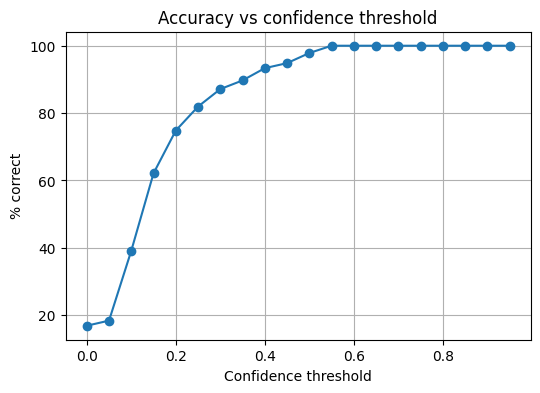

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(threshold_df["threshold"], threshold_df["pct_true"], marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("% correct")
plt.title("Accuracy vs confidence threshold")
plt.grid(True)
plt.show()

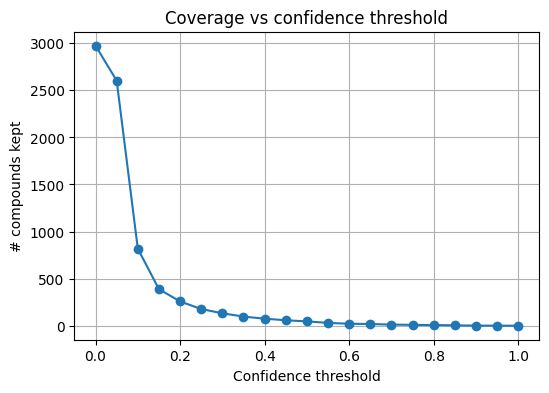

In [11]:
plt.figure(figsize=(6,4))
plt.plot(threshold_df["threshold"], threshold_df["n_compounds"], marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("# compounds kept")
plt.title("Coverage vs confidence threshold")
plt.grid(True)
plt.show()

## Correlation with original MoA proportions

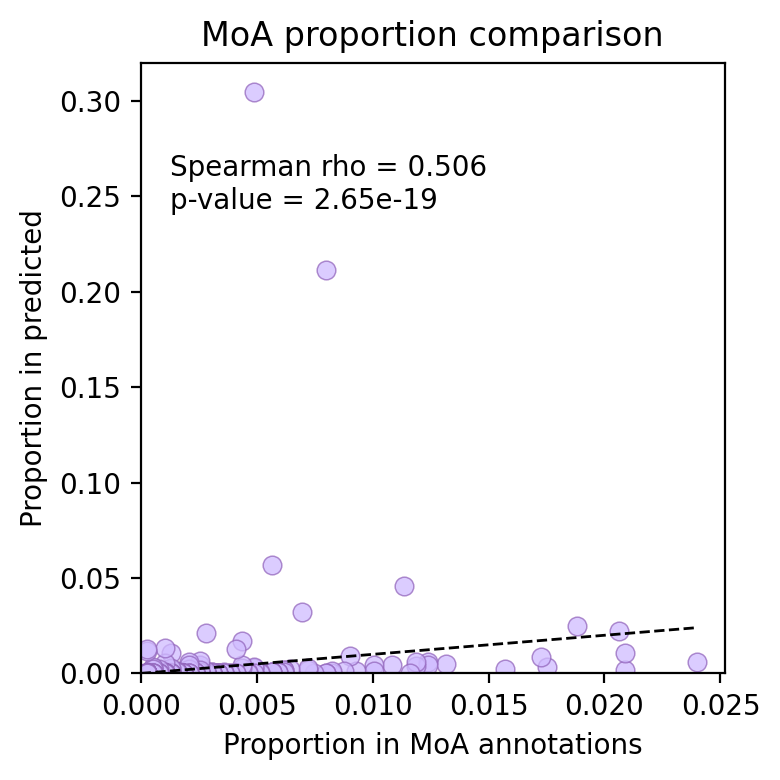

,cmp_info_moa_prop,compound_top_prop,abs_diff
Tyrosine kinase inhibitor,0.004899,0.304706,0.299806
HDAC inhibitor,0.007994,0.211292,0.203298
Estrogen receptor antagonist,0.005673,0.057010,0.051337
Estrogen receptor agonist,0.011346,0.045711,0.034365
PPAR receptor agonist,0.006962,0.032042,0.025080
Glucocorticoid receptor agonist,0.020887,0.001985,0.018902
Insulin sensitizer,0.002837,0.020935,0.018098
Serotonin receptor antagonist,0.023981,0.006242,0.017739
Acetylcholine receptor antagonist,0.017535,0.003521,0.014014
Adrenergic receptor agonist,0.015730,0.002113,0.013617


In [20]:
from scipy.stats import spearmanr

def fractional_moa_proportions(series, sep=";"):
    counts = {}
    total_weight = 0.0

    for value in series.dropna():
        moas = [m.strip() for m in str(value).split(sep) if m.strip()]
        if not moas:
            continue

        weight = 1.0 / len(moas)
        total_weight += 1.0

        for moa in moas:
            counts[moa] = counts.get(moa, 0.0) + weight

    return pd.Series(counts, dtype=float).sort_values(ascending=False) / total_weight

cmp_info_moa_prop = cmp_info_moa["moa"].value_counts(normalize=True)
compound_top_prop = fractional_moa_proportions(compound_top["top_moa"])

moa_prop_comparison = pd.concat(
    [
        cmp_info_moa_prop.rename("cmp_info_moa_prop"),
        compound_top_prop.rename("compound_top_prop"),
    ],
    axis=1,
).dropna()

rho, pval = spearmanr(
    moa_prop_comparison["cmp_info_moa_prop"],
    moa_prop_comparison["compound_top_prop"],
)

plt.figure(figsize=(4,4), dpi = 200)
sns.scatterplot(
    data=moa_prop_comparison,
    x="cmp_info_moa_prop",
    y="compound_top_prop",
    s=45,
    alpha=0.75, 
    color = sns.color_palette("pastel")[4],
    edgecolor = sns.color_palette("tab10")[4],
)

x_max = moa_prop_comparison["cmp_info_moa_prop"].max()
y_max = moa_prop_comparison["compound_top_prop"].max()
diag_max = min(x_max, y_max)
plt.plot([0, diag_max], [0, diag_max], linestyle="--", color="black", linewidth=1)
plt.xlim(0, x_max * 1.05)
plt.ylim(0, y_max * 1.05)
plt.xlabel("Proportion in MoA annotations")
plt.ylabel("Proportion in predicted")
plt.title("MoA proportion comparison")
plt.text(
    0.05,
    0.85,
    f"Spearman rho = {rho:.3f}\np-value = {pval:.2e}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    
)
plt.tight_layout()
plt.show()

moa_prop_comparison["abs_diff"] = (
    moa_prop_comparison["compound_top_prop"] - moa_prop_comparison["cmp_info_moa_prop"]
).abs()
moa_prop_comparison.sort_values("abs_diff", ascending=False).head(15)


## Confidence per most common MoAs

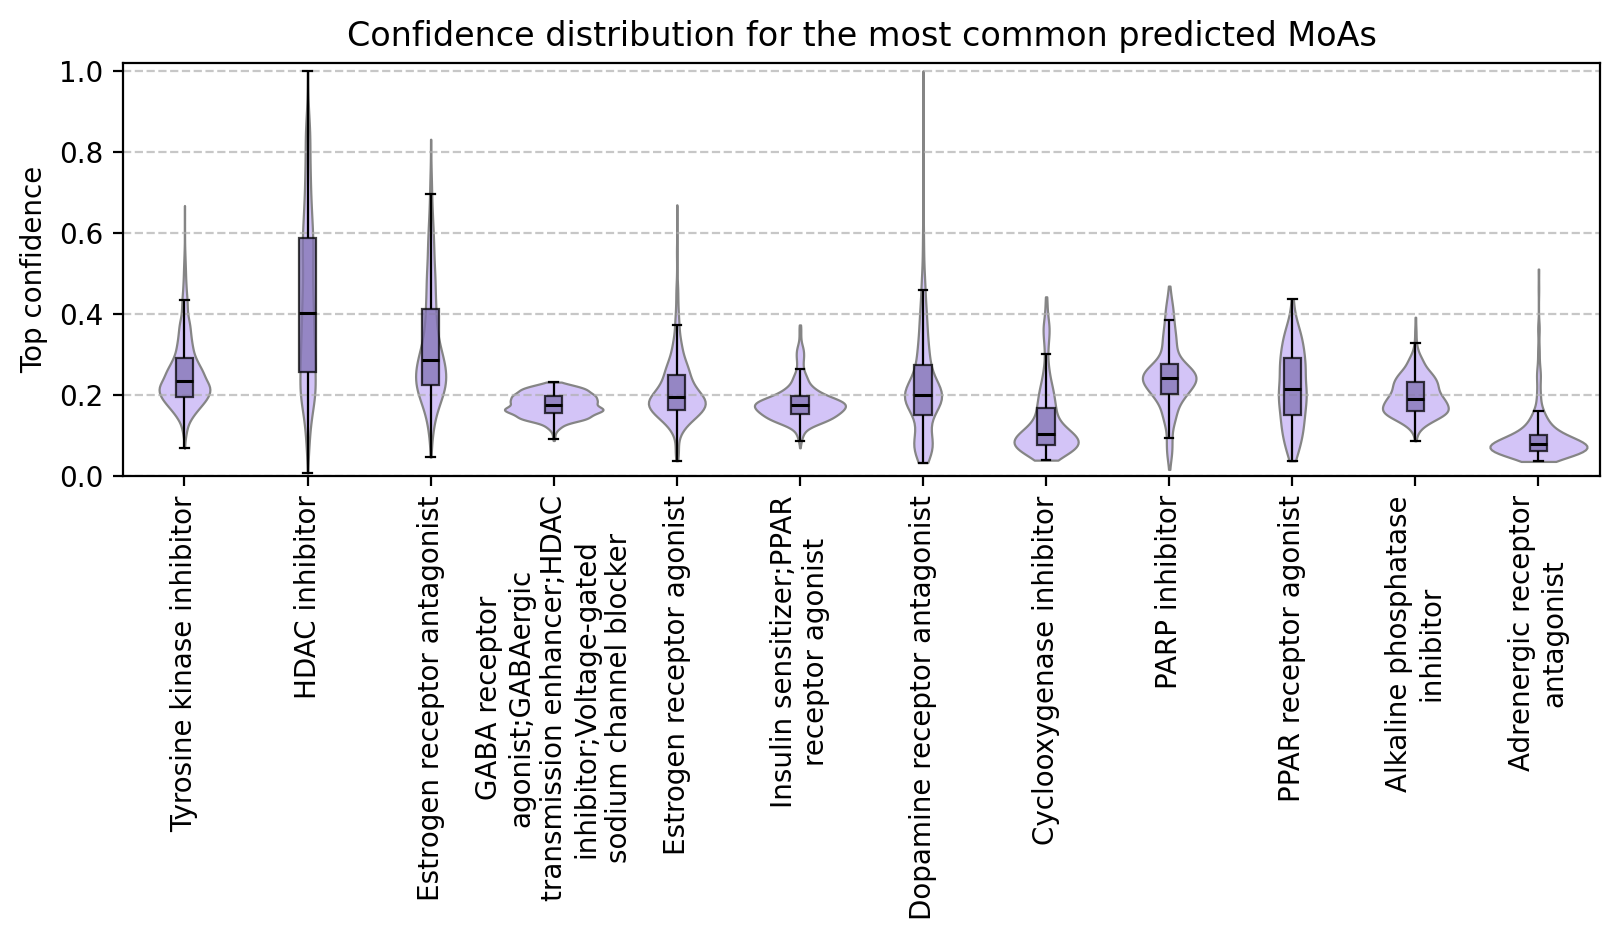

,count,median,mean
top_moa,,,
Tyrosine kinase inhibitor,9519,0.233325,0.251949
HDAC inhibitor,6203,0.400696,0.431200
Estrogen receptor antagonist,1781,0.286161,0.326691
GABA receptor agonist;GABAergic transmission enhancer;HDAC inhibitor;Voltage-gated sodium channel blocker,1591,0.175216,0.175290
Estrogen receptor agonist,1428,0.195174,0.211999
Insulin sensitizer;PPAR receptor agonist,1190,0.173842,0.180946
Dopamine receptor antagonist,771,0.200339,0.220321
Cyclooxygenase inhibitor,694,0.101946,0.133946
PARP inhibitor,528,0.241951,0.244451


In [21]:
import textwrap

top_n_moas = 12
top_moa_order = compound_top["top_moa"].value_counts().head(top_n_moas).index.tolist()
top_moa_labels = ["\n".join(textwrap.wrap(moa, width=28, break_long_words=False)) for moa in top_moa_order]

compound_top_common = compound_top[compound_top["top_moa"].isin(top_moa_order)].copy()
compound_top_common["top_moa"] = pd.Categorical(
    compound_top_common["top_moa"],
    categories=top_moa_order,
    ordered=True,
)

plt.figure(figsize=(8.2, 4.8), dpi=200)
sns.violinplot(
    data=compound_top_common,
    x="top_moa",
    y="top_conf",
    order=top_moa_order,
    inner=None,
    cut=0,
    linewidth=0.8,
    color=sns.color_palette("pastel")[4],
)
sns.boxplot(
    data=compound_top_common,
    x="top_moa",
    y="top_conf",
    order=top_moa_order,
    width=0.14,
    showcaps=True,
    boxprops={"facecolor": sns.color_palette("deep")[4], "alpha": 0.75, "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"linewidth": 0.8, "color": "black"},
    capprops={"linewidth": 0.8, "color": "black"},
    medianprops={"color": "black", "linewidth": 1.1},
    flierprops={"marker": "", "markersize": 0},
)
plt.xticks(range(len(top_moa_order)), top_moa_labels, rotation=90, ha="center")
plt.xlabel("")
plt.grid(True, axis="y", linestyle="--", alpha=0.7, zorder=0)
plt.ylabel("Top confidence")
plt.title("Confidence distribution for the most common predicted MoAs")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

compound_top_common.groupby("top_moa", observed=False)["top_conf"].agg(["count", "median", "mean"]).sort_values("count", ascending=False)
